# Final Team Project: Music Genre and Composer Classification Using Deep Learning

**Team Members**
- Andrew Blumhardt
- Brian Covington
- Erika Gallegos

**University:** University of San Diego  
**Course:** AAI-511: Neural Networks and Deep Learning  
**Due Date:** August 10, 2026

## Project Objective

The official assignment title includes both music genre and composer
classification. This notebook focuses on the **composer-classification portion**
of the project by classifying MIDI compositions from four required composers:
**Bach, Beethoven, Chopin, and Mozart**.

Two deep learning approaches are developed and compared:

- An **LSTM** model that analyzes ordered sequences of musical notes.
- A **CNN** model that analyzes piano-roll images representing pitch over time.

The notebook includes direct Kaggle data collection, preprocessing, exploratory
analysis, data augmentation, feature extraction, model development, training,
optimization, evaluation, visualizations, and a final comparison of the two
architectures.

## 1. Academic Integrity and AI-Assistance Disclosure

Generative AI was used to assist with notebook organization, code review,
debugging, and editing of explanatory text. The team reviewed and modified the
suggestions and remains responsible for understanding the code, running the
experiments, validating the outputs, and interpreting the results.

The final reported metrics must come from execution of this notebook. AI tools
were not used to create or alter experimental results.

## 2. Environment Setup

This notebook is designed for **Google Colab**. The `kagglehub` package
downloads the public dataset directly from Kaggle, and `pretty_midi` is used to
read and convert MIDI files.

### Select a GPU before training

The CNN can take several minutes per epoch on a CPU because each example is a
128 × 256 piano-roll matrix and the augmented training set contains more than
3,000 examples. Before running the notebook:

1. Select **Runtime** in Google Colab.
2. Select **Change runtime type**.
3. Set **Hardware accelerator** to **GPU**.
4. Save the setting.
5. Run the environment-check cell below and confirm that at least one GPU is
   listed.

A GPU mainly accelerates the LSTM and CNN training sections. MIDI parsing and
feature extraction are primarily CPU-based, so those earlier sections may not
change substantially in speed.

In [1]:
# Install the packages that are not included in every Colab runtime.
# The -q option keeps installation output concise.
!pip -q install kagglehub pretty_midi

print("Package installation completed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 53.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.7 MB/s eta 0:00:00
Package installation completed successfully.


In [2]:
# Standard-library imports used for file handling, pattern matching,
# reproducibility, and timing.
import os
import re
import random
import time
from pathlib import Path

# Data processing and visualization libraries.
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi
import tensorflow as tf

# Scikit-learn utilities for splitting, encoding, weighting, and evaluation.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

# TensorFlow/Keras components for the LSTM and CNN architectures.
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    Callback
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam

# Use one fixed seed throughout the notebook so that repeated runs are
# as reproducible as possible.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Confirm the TensorFlow version and whether Colab has provided a GPU.
gpu_devices = tf.config.list_physical_devices("GPU")

print("Environment validation completed.")
print("TensorFlow version:", tf.__version__)
print("GPU devices detected:", gpu_devices)

if gpu_devices:
    print("GPU acceleration is available for model training.")
else:
    print(
        "WARNING: No GPU was detected. The notebook will still run, "
        "but CNN epochs may take several minutes each. In Colab, select "
        "Runtime > Change runtime type > GPU before training."
    )

Environment validation completed.
TensorFlow version: 2.20.0
GPU devices detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU acceleration is available for model training.


## 3. Data Collection from Kaggle

The notebook downloads the **midi_classic_music** dataset directly from Kaggle.
The dataset contains MIDI files from many composers, so only files associated
with Bach, Beethoven, Chopin, and Mozart are retained.

Because this is a public Kaggle dataset, `kagglehub` will normally download it
without requiring a personal Google Drive connection. Kaggle may request
authentication if its access requirements change.

In [3]:
# Kaggle dataset identifier used by kagglehub.
KAGGLE_DATASET = "blanderbuss/midi-classic-music"

# Download and extract the most recent available version of the dataset.
dataset_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))

# Validate that the returned location exists before continuing.
if not dataset_path.exists():
    raise FileNotFoundError(
        f"Kaggle download path does not exist: {dataset_path}"
    )

print("Kaggle download completed successfully.")
print("Dataset location:", dataset_path)

100%|██████████| 68.2M/68.2M [00:00<00:00, 116MB/s]

Extracting files...


Kaggle download completed successfully.
Dataset location: /root/.cache/kagglehub/datasets/blanderbuss/midi-classic-music/versions/1


## 4. Dataset Selection and Inspection

Composer labels are derived from both folder names and filenames because public
MIDI datasets do not always use one consistent directory structure. The
matching rules are intentionally limited to the four composers required by this
project.

The distribution is inspected before modeling because unequal class sizes can
cause a model to favor the largest class. In this dataset, **Bach**, rather than
Mozart, has substantially more files than the other composers. The notebook
addresses this imbalance through:

- stratified training, validation, and test splits,
- balanced class weights during training, and
- macro-averaged precision, recall, and F1 during evaluation.

The full Bach collection is retained rather than discarded because downsampling
would remove potentially useful musical examples.

In [4]:
# Limit the project to the four composers required by the assignment.
REQUIRED_COMPOSERS = ["Bach", "Beethoven", "Chopin", "Mozart"]

# Patterns account for common forms such as "Bach" and "J. S. Bach".
COMPOSER_PATTERNS = {
    "Bach": r"\bbach\b|j\.?s\.?\s*bach",
    "Beethoven": r"\bbeethoven\b",
    "Chopin": r"\bchopin\b",
    "Mozart": r"\bmozart\b"
}


def identify_composer(path):
    """Return the matching required composer, or None when no match exists."""
    # Normalize separators so filenames and folders can be searched consistently.
    text = str(path).lower().replace("_", " ").replace("-", " ")

    for composer, pattern in COMPOSER_PATTERNS.items():
        if re.search(pattern, text, flags=re.IGNORECASE):
            return composer

    return None


# Search recursively for common upper- and lowercase MIDI extensions.
midi_paths = sorted(
    list(dataset_path.rglob("*.mid"))
    + list(dataset_path.rglob("*.midi"))
    + list(dataset_path.rglob("*.MID"))
    + list(dataset_path.rglob("*.MIDI"))
)

# Retain only MIDI files associated with one of the required composers.
records = []

for path in midi_paths:
    composer = identify_composer(path)

    if composer is not None:
        records.append({
            "file_path": str(path),
            "file_name": path.name,
            "composer": composer
        })

# Remove duplicate paths and reset the dataframe index.
dataset_df = (
    pd.DataFrame(records)
    .drop_duplicates("file_path")
    .reset_index(drop=True)
)

# Verify that all four composer classes were found.
observed = sorted(dataset_df["composer"].unique())
missing = sorted(set(REQUIRED_COMPOSERS) - set(observed))

if missing:
    raise RuntimeError(
        f"Missing required composer classes: {missing}. "
        "Review the filename-labeling rules or Kaggle dataset structure."
    )

print("Dataset-selection validation completed.")
print(f"All MIDI files discovered: {len(midi_paths)}")
print(f"Files retained for required composers: {len(dataset_df)}")
print("Composer classes found:", observed)
display(dataset_df.head())

Dataset-selection validation completed.
All MIDI files discovered: 4712
Files retained for required composers: 1642
Composer classes found: ['Bach', 'Beethoven', 'Chopin', 'Mozart']


,file_path,file_name,composer
0,/root/.cache/kagglehub/datasets/blanderbuss/mi...,AveMaria.mid,Bach
1,/root/.cache/kagglehub/datasets/blanderbuss/mi...,01 Menuet.mid,Bach
2,/root/.cache/kagglehub/datasets/blanderbuss/mi...,02 Menuet.mid,Bach
3,/root/.cache/kagglehub/datasets/blanderbuss/mi...,03 Menuet.mid,Bach
4,/root/.cache/kagglehub/datasets/blanderbuss/mi...,04 Menuet.mid,Bach


,MIDI Files
composer,
Bach,1036
Beethoven,213
Chopin,136
Mozart,257


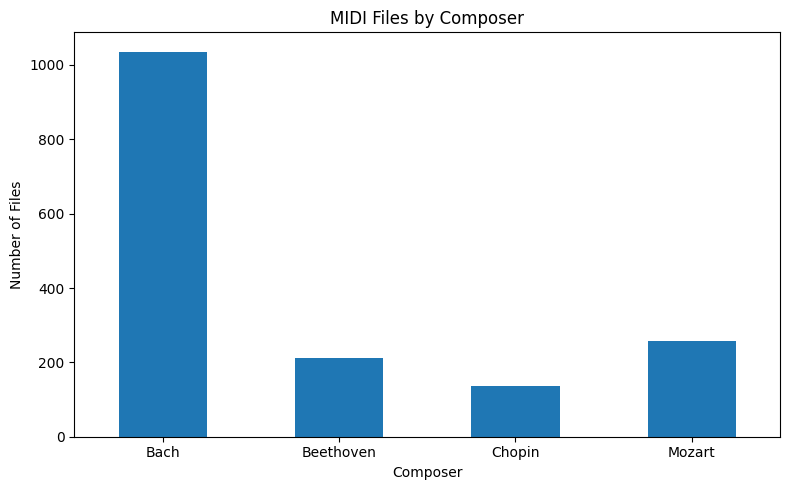

Class-distribution validation completed.
Bach is the largest class with 1036 files.
Chopin is the smallest class with 136 files.
Largest-to-smallest class ratio: 7.62:1
The imbalance will be addressed with stratified splits, balanced class weights, and macro-averaged evaluation metrics.


In [5]:
# Count the files for each required composer in a consistent display order.
class_counts = (
    dataset_df["composer"]
    .value_counts()
    .reindex(REQUIRED_COMPOSERS)
)

# Calculate a simple imbalance ratio: largest class divided by smallest class.
largest_class = class_counts.idxmax()
smallest_class = class_counts.idxmin()
imbalance_ratio = class_counts.max() / class_counts.min()

display(class_counts.rename("MIDI Files").to_frame())

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("MIDI Files by Composer")
plt.xlabel("Composer")
plt.ylabel("Number of Files")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Class-distribution validation completed.")
print(
    f"{largest_class} is the largest class with "
    f"{class_counts.max()} files."
)
print(
    f"{smallest_class} is the smallest class with "
    f"{class_counts.min()} files."
)
print(f"Largest-to-smallest class ratio: {imbalance_ratio:.2f}:1")
print(
    "The imbalance will be addressed with stratified splits, "
    "balanced class weights, and macro-averaged evaluation metrics."
)

## 5. Preprocessing and Feature Extraction

Each MIDI file is processed once. The preprocessing function extracts:

- **Note sequence:** ordered MIDI pitch values for the LSTM.
- **Tempo:** estimated beats per minute for descriptive analysis.
- **Piano roll:** a fixed-size pitch-by-time matrix for the CNN.
- **Duration and velocity summaries:** additional descriptive musical features.

Files that cannot be parsed or contain too few notes are excluded and counted.
The models use notes and piano rolls directly; tempo, duration, and velocity are
included in the analysis to document the musical characteristics extracted from
the MIDI files.

In [6]:
# Minimum sequence length used to exclude files with too little musical data.
MIN_NOTES = 20

# Fixed input dimensions used by the LSTM and CNN models.
MAX_SEQUENCE_LENGTH = 500
PIANO_ROLL_TIME_STEPS = 256
PIANO_ROLL_PITCHES = 128


def resize_time_axis(matrix, target_steps):
    """Resize a pitch-by-time matrix with nearest-neighbor time sampling."""
    # Return an empty fixed-size matrix when a MIDI file has no time frames.
    if matrix.shape[1] == 0:
        return np.zeros(
            (matrix.shape[0], target_steps),
            dtype=np.float32
        )

    # Select evenly spaced source columns across the full composition.
    source_indices = np.linspace(
        0,
        matrix.shape[1] - 1,
        target_steps
    ).astype(int)

    return matrix[:, source_indices].astype(np.float32)


def extract_midi_features(file_path):
    """Extract note, tempo, summary, and piano-roll features from one file."""
    # Parse the MIDI file once and reuse the result for all feature types.
    midi = pretty_midi.PrettyMIDI(file_path)

    notes = []
    durations = []
    velocities = []

    # Ignore drum tracks because percussion pitches do not correspond to
    # melodic notes in the same way as standard MIDI instruments.
    for instrument in midi.instruments:
        if instrument.is_drum:
            continue

        for midi_note in instrument.notes:
            notes.append(midi_note)
            durations.append(midi_note.end - midi_note.start)
            velocities.append(midi_note.velocity)

    # Preserve the musical order of notes for the LSTM sequence.
    notes = sorted(notes, key=lambda item: (item.start, item.pitch))

    if len(notes) < MIN_NOTES:
        return None

    pitch_sequence = [item.pitch for item in notes]

    # Use the first encoded tempo or a conventional 120 BPM fallback.
    _, tempi = midi.get_tempo_changes()
    tempo_bpm = float(tempi[0]) if len(tempi) else 120.0

    # Convert the composition into a fixed-size normalized piano roll.
    piano_roll = midi.get_piano_roll(fs=8)
    piano_roll = resize_time_axis(
        piano_roll,
        PIANO_ROLL_TIME_STEPS
    )

    if piano_roll.max() > 0:
        piano_roll = piano_roll / piano_roll.max()

    return {
        "pitch_sequence": pitch_sequence,
        "tempo_bpm": tempo_bpm,
        "mean_duration": float(np.mean(durations)),
        "mean_velocity": float(np.mean(velocities)),
        "piano_roll": piano_roll
    }


print("Feature-extraction functions defined successfully.")
print(
    "Configured inputs: "
    f"LSTM length={MAX_SEQUENCE_LENGTH}, "
    f"CNN shape=({PIANO_ROLL_PITCHES}, {PIANO_ROLL_TIME_STEPS})."
)

Feature-extraction functions defined successfully.
Configured inputs: LSTM length=500, CNN shape=(128, 256).


In [7]:
from tqdm.auto import tqdm

# Store successful feature records separately from excluded or failed files.
feature_records = []
failed_files = []
short_files = []

# Process each retained MIDI file and show progress during the longer CPU step.
for row in tqdm(
    dataset_df.itertuples(index=False),
    total=len(dataset_df),
    desc="Processing MIDI files"
):
    try:
        features = extract_midi_features(row.file_path)

        if features is None:
            short_files.append(row.file_path)
            continue

        feature_records.append({
            "file_path": row.file_path,
            "composer": row.composer,
            **features
        })

    except Exception as error:
        failed_files.append({
            "file_path": row.file_path,
            "error": str(error)
        })

# Convert all successful records into one modeling dataframe.
features_df = pd.DataFrame(feature_records)

if features_df.empty:
    raise RuntimeError("No MIDI files were successfully processed.")

processing_rate = len(features_df) / len(dataset_df)

print("MIDI preprocessing validation completed.")
print(f"Files retained before parsing: {len(dataset_df)}")
print(f"Files successfully processed: {len(features_df)}")
print(f"Files excluded as too short: {len(short_files)}")
print(f"Files that failed parsing: {len(failed_files)}")
print(f"Successful processing rate: {processing_rate:.2%}")
display(features_df.head())

Processing MIDI files:   0%|          | 0/1642 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


MIDI preprocessing validation completed.
Files retained before parsing: 1642
Files successfully processed: 1640
Files excluded as too short: 0
Files that failed parsing: 2
Successful processing rate: 99.88%


,file_path,composer,pitch_sequence,tempo_bpm,mean_duration,mean_velocity,piano_roll
0,/root/.cache/kagglehub/datasets/blanderbuss/mi...,Bach,"[41, 53, 57, 60, 65, 69, 60, 65, 69, 53, 57, 6...",120.000000,0.295135,33.857503,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
1,/root/.cache/kagglehub/datasets/blanderbuss/mi...,Bach,"[53, 72, 57, 74, 76, 77, 55, 76, 57, 77, 76, 7...",104.999921,0.408848,100.000000,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
2,/root/.cache/kagglehub/datasets/blanderbuss/mi...,Bach,"[55, 59, 62, 74, 67, 69, 57, 71, 72, 59, 74, 6...",130.000130,0.389438,100.000000,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,/root/.cache/kagglehub/datasets/blanderbuss/mi...,Bach,"[55, 82, 81, 79, 53, 81, 74, 74, 51, 79, 67, 6...",120.000000,0.497688,100.000000,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,/root/.cache/kagglehub/datasets/blanderbuss/mi...,Bach,"[55, 67, 71, 74, 79, 50, 69, 78, 43, 79, 47, 5...",120.000000,0.295553,100.000000,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


### 5.1 Descriptive Feature Analysis

These summaries provide the additional analysis and visualizations requested by
the rubric. They are not test-set performance metrics and should not be
interpreted as evidence that one composer is inherently faster, louder, or more
complex than another.

In [8]:
# Summarize extracted musical characteristics by composer.
summary_table = (
    features_df.groupby("composer")
    .agg(
        files=("file_path", "count"),
        mean_tempo_bpm=("tempo_bpm", "mean"),
        median_tempo_bpm=("tempo_bpm", "median"),
        mean_note_duration=("mean_duration", "mean"),
        mean_velocity=("mean_velocity", "mean")
    )
    .round(2)
    .reindex(REQUIRED_COMPOSERS)
)

display(summary_table)

print("Descriptive feature summary generated successfully.")
print(
    "These values describe the available MIDI files and are not "
    "test-set classification results."
)

,files,mean_tempo_bpm,median_tempo_bpm,mean_note_duration,mean_velocity
composer,,,,,
Bach,1036,95.63,96.0,0.47,89.41
Beethoven,212,129.35,119.5,0.34,72.52
Chopin,136,126.26,120.0,0.36,66.11
Mozart,256,115.05,120.0,0.35,78.12


Descriptive feature summary generated successfully.
These values describe the available MIDI files and are not test-set classification results.


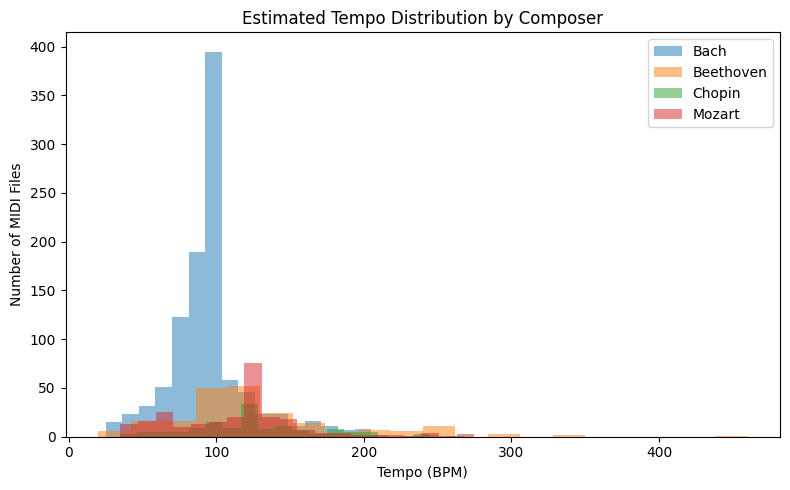

Tempo-distribution visualization generated successfully.


In [9]:
# Plot overlapping tempo histograms to compare dataset distributions.
plt.figure(figsize=(8, 5))

for composer in REQUIRED_COMPOSERS:
    values = features_df.loc[
        features_df["composer"] == composer,
        "tempo_bpm"
    ]
    plt.hist(values, bins=20, alpha=0.5, label=composer)

plt.title("Estimated Tempo Distribution by Composer")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Number of MIDI Files")
plt.legend()
plt.tight_layout()
plt.show()

print("Tempo-distribution visualization generated successfully.")

## 6. Train, Validation, and Test Split

The original MIDI files are divided into training, validation, and test sets
before augmentation. This prevents transposed versions of the same composition
from appearing in both training and evaluation data.

The split is stratified by composer:

- 64% training
- 16% validation
- 20% test

In [10]:
# Encode composer names as integer class labels for TensorFlow.
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(features_df["composer"])
class_names = list(label_encoder.classes_)

# Keep indices so that note sequences and piano rolls use identical splits.
indices = np.arange(len(features_df))

# Reserve 20% of original compositions for final testing.
train_indices, test_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all
)

# Split the remaining data into 80% training and 20% validation.
# This produces an overall 64/16/20 train/validation/test allocation.
train_indices, validation_indices = train_test_split(
    train_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all[train_indices]
)

y_train_original = y_all[train_indices]
y_validation = y_all[validation_indices]
y_test = y_all[test_indices]

# Confirm that stratification preserved all four classes in every split.
split_summary = pd.DataFrame({
    "Training": pd.Series(y_train_original).value_counts().sort_index(),
    "Validation": pd.Series(y_validation).value_counts().sort_index(),
    "Test": pd.Series(y_test).value_counts().sort_index()
})
split_summary.index = class_names

print("Data-split validation completed.")
print("Training files:", len(train_indices))
print("Validation files:", len(validation_indices))
print("Test files:", len(test_indices))
print("Class order:", class_names)
display(split_summary)

Data-split validation completed.
Training files: 1049
Validation files: 263
Test files: 328
Class order: ['Bach', 'Beethoven', 'Chopin', 'Mozart']


,Training,Validation,Test
Bach,663,166,207
Beethoven,135,34,43
Chopin,87,22,27
Mozart,164,41,51


## 7. Training-Only Data Augmentation

Pitch transposition is used as a musically reasonable augmentation technique.
Each training composition is shifted two semitones upward and two semitones
downward. Composer identity is preserved while the model receives additional
pitch variation.

Validation and test data are not augmented.

In [11]:
# Two musically modest pitch shifts create additional training examples.
PITCH_SHIFTS = (-2, 2)


def transpose_sequence(sequence, semitones):
    """Shift valid MIDI note values while preserving sequence order."""
    return [
        pitch + semitones
        for pitch in sequence
        if 0 <= pitch + semitones <= 127
    ]


def transpose_piano_roll(piano_roll, semitones):
    """Shift a piano roll vertically along its pitch axis."""
    shifted = np.zeros_like(piano_roll)

    if semitones > 0:
        shifted[semitones:, :] = piano_roll[:-semitones, :]
    elif semitones < 0:
        shifted[:semitones, :] = piano_roll[-semitones:, :]
    else:
        shifted = piano_roll.copy()

    return shifted


print("Training-only augmentation functions defined successfully.")
print("Configured pitch shifts:", PITCH_SHIFTS)

Training-only augmentation functions defined successfully.
Configured pitch shifts: (-2, 2)


## 8. LSTM Data Preparation

MIDI pitches range from 0 to 127. One is added to each pitch so that zero can be
reserved for padding. Sequences are padded or truncated to 500 notes.

In [12]:
def encode_sequence(sequence):
    """Reserve zero for padding by shifting MIDI pitch values upward by one."""
    return [pitch + 1 for pitch in sequence]


training_sequences = []
training_labels = []

# Add each original training sequence and two transposed copies.
for index in train_indices:
    original_sequence = features_df.iloc[index]["pitch_sequence"]
    label = y_all[index]

    training_sequences.append(encode_sequence(original_sequence))
    training_labels.append(label)

    for shift in PITCH_SHIFTS:
        augmented = transpose_sequence(original_sequence, shift)
        training_sequences.append(encode_sequence(augmented))
        training_labels.append(label)

# Validation and test sequences remain unaugmented.
validation_sequences = [
    encode_sequence(features_df.iloc[index]["pitch_sequence"])
    for index in validation_indices
]
test_sequences = [
    encode_sequence(features_df.iloc[index]["pitch_sequence"])
    for index in test_indices
]

# Pad or truncate every note sequence to one fixed model input length.
X_lstm_train = pad_sequences(
    training_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)
X_lstm_validation = pad_sequences(
    validation_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)
X_lstm_test = pad_sequences(
    test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

y_train = np.asarray(training_labels)

# Balanced class weights make errors on smaller composer classes count more
# heavily during optimization without removing any Bach compositions.
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        np.unique(y_train),
        class_weight_values
    )
}

class_weight_table = pd.DataFrame({
    "Composer": class_names,
    "Class Weight": [
        class_weights[index]
        for index in range(len(class_names))
    ]
}).round(4)

print("LSTM data-preparation validation completed.")
print("Original training files:", len(train_indices))
print("Augmented LSTM training sequences:", len(X_lstm_train))
print("LSTM training shape:", X_lstm_train.shape)
print("LSTM validation shape:", X_lstm_validation.shape)
print("LSTM test shape:", X_lstm_test.shape)
display(class_weight_table)

LSTM data-preparation validation completed.
Original training files: 1049
Augmented LSTM training sequences: 3147
LSTM training shape: (3147, 500)
LSTM validation shape: (263, 500)
LSTM test shape: (328, 500)


,Composer,Class Weight
0,Bach,0.3956
1,Beethoven,1.9426
2,Chopin,3.0144
3,Mozart,1.5991


## 9. LSTM Model

The LSTM analyzes the ordered note sequence from each composition. An embedding
layer converts integer MIDI pitches into learned vectors, the recurrent layer
models relationships across the sequence, and dropout reduces overfitting.

This is one selected model configuration. Epochs do not test different
architectures; each epoch gives the same model another complete pass through
the training data so that its learned weights can improve.

In [13]:
# Build a moderate-size recurrent model suitable for a Colab environment.
lstm_model = Sequential([
    # One integer represents each note in the padded 500-note sequence.
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    # Convert discrete MIDI pitches into trainable 64-value vectors.
    Embedding(
        input_dim=129,
        output_dim=64,
        mask_zero=True
    ),

    # Learn patterns across the ordered note sequence.
    LSTM(96),

    # Regularize the learned representation before classification.
    Dropout(0.35),
    Dense(64, activation="relu"),
    Dropout(0.25),

    # Return probabilities for the four composer classes.
    Dense(len(class_names), activation="softmax")
])

# Compile for a four-class integer-label classification problem.
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("LSTM model created and compiled successfully.")
lstm_model.summary()

LSTM model created and compiled successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 500, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 96)             │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,548 (299.02 KB)

 Trainable params: 76,548 (299.02 KB)

 Non-trainable params: 0 (0.00 B)

### 9.1 LSTM Training, Epochs, and Optimization

An **epoch** is one complete pass through the training set. Multiple epochs give
the model repeated opportunities to refine its weights. A useful comparison is
rereading a textbook: early readings produce the largest gains, later readings
produce smaller gains, and eventually additional rereading may add little or
encourage memorization.

Training is configured for a **maximum of 30 epochs**, not a mandatory 30.
Early stopping monitors validation loss and ends training after five epochs
without improvement. It then restores the weights from the best epoch. Fewer
than 30 completed epochs therefore normally means that additional training was
no longer improving performance on unseen validation data.

The LSTM and CNN may stop after different numbers of epochs because they use
different representations, architectures, parameter counts, and learning
rates. The CNN may need more epochs even though each CNN epoch also takes
longer.

Runtime depends heavily on the selected Colab hardware. In the reviewed run,
LSTM epochs generally took about **48–84 seconds**, while CNN epochs generally
took about **6–7 minutes** because no GPU was detected. Those CNN timings are
plausible for CPU execution but are a strong reason to select a GPU before
training.

`ReduceLROnPlateau` reduces the learning rate when validation loss stalls,
allowing smaller weight adjustments before early stopping decides that further
training is unlikely to help.

In [14]:
MAX_EPOCHS = 30


class EpochTimingCallback(Callback):
    """Record and report the duration of every training epoch."""

    def on_train_begin(self, logs=None):
        self.epoch_times = []
        self.training_start = time.perf_counter()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.perf_counter() - self.epoch_start
        self.epoch_times.append(elapsed)
        print(f"Epoch {epoch + 1} duration: {elapsed:.1f} seconds")

    def on_train_end(self, logs=None):
        total = time.perf_counter() - self.training_start
        print(f"Total training time: {total / 60:.2f} minutes")


# Stop when validation loss has stopped improving and restore the best weights.
lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Lower the learning rate when validation improvement slows.
lstm_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Report per-epoch and total runtime.
lstm_timer = EpochTimingCallback()

lstm_history = lstm_model.fit(
    X_lstm_train,
    y_train,
    validation_data=(X_lstm_validation, y_validation),
    epochs=MAX_EPOCHS,
    batch_size=32,
    callbacks=[
        lstm_early_stopping,
        lstm_reduce_lr,
        lstm_timer
    ],
    class_weight=class_weights,
    verbose=1
)

lstm_epochs_completed = len(lstm_history.history["loss"])
lstm_best_epoch = int(
    np.argmin(lstm_history.history["val_loss"]) + 1
)
lstm_average_epoch_time = float(np.mean(lstm_timer.epoch_times))

print("LSTM training validation completed.")
print(
    f"LSTM completed {lstm_epochs_completed} of a maximum "
    f"{MAX_EPOCHS} epochs."
)
print(f"Best LSTM validation-loss epoch: {lstm_best_epoch}")
print(
    f"Average LSTM epoch duration: "
    f"{lstm_average_epoch_time:.1f} seconds"
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2186 - loss: 1.4030Epoch 1 duration: 9.0 seconds
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.3607 - loss: 1.3647 - val_accuracy: 0.5894 - val_loss: 1.1654 - learning_rate: 0.0010
Epoch 2/30
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5236 - loss: 1.3220Epoch 2 duration: 2.2 seconds
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4932 - loss: 1.3029 - val_accuracy: 0.4373 - val_loss: 1.2767 - learning_rate: 0.0010
Epoch 3/30
98/99 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4583 - loss: 1.3393
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 3 duration: 2.2 seconds
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4280 - loss: 1.3325 - val_accuracy: 0.3650 - val_loss: 1.3452 - learning_rate: 0.0010
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3062 - loss: 1.3701Epoch 4 duration: 2.2 seconds
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accur

## 10. CNN Data Preparation

The piano-roll matrices are augmented using the same two pitch shifts as the
LSTM sequences. A final channel dimension is added for the CNN.

In [15]:
training_rolls = []
cnn_training_labels = []

# Add each original training piano roll and two pitch-shifted copies.
for index in train_indices:
    original_roll = features_df.iloc[index]["piano_roll"]
    label = y_all[index]

    training_rolls.append(original_roll)
    cnn_training_labels.append(label)

    for shift in PITCH_SHIFTS:
        training_rolls.append(
            transpose_piano_roll(original_roll, shift)
        )
        cnn_training_labels.append(label)

# Convert lists into four-dimensional CNN tensors:
# examples × pitch × time × channel.
X_cnn_train = np.asarray(
    training_rolls,
    dtype=np.float32
)[..., np.newaxis]

# Validation and test piano rolls remain unaugmented.
X_cnn_validation = np.asarray(
    [
        features_df.iloc[index]["piano_roll"]
        for index in validation_indices
    ],
    dtype=np.float32
)[..., np.newaxis]

X_cnn_test = np.asarray(
    [
        features_df.iloc[index]["piano_roll"]
        for index in test_indices
    ],
    dtype=np.float32
)[..., np.newaxis]

y_cnn_train = np.asarray(cnn_training_labels)

print("CNN data-preparation validation completed.")
print("Original training files:", len(train_indices))
print("Augmented CNN training examples:", len(X_cnn_train))
print("CNN training shape:", X_cnn_train.shape)
print("CNN validation shape:", X_cnn_validation.shape)
print("CNN test shape:", X_cnn_test.shape)

CNN data-preparation validation completed.
Original training files: 1049
Augmented CNN training examples: 3147
CNN training shape: (3147, 128, 256, 1)
CNN validation shape: (263, 128, 256, 1)
CNN test shape: (328, 128, 256, 1)


## 11. CNN Model

The CNN uses three convolutional blocks to identify local pitch-and-time
patterns. Global average pooling reduces the number of parameters compared with
a large flattened dense layer and helps limit overfitting.

In [16]:
# Build a convolutional model that learns local pitch-and-time patterns.
cnn_model = Sequential([
    Input(shape=X_cnn_train.shape[1:]),

    # First convolutional block learns lower-level local patterns.
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.20),

    # Second block learns more complex combinations of those patterns.
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third block develops higher-level piano-roll features.
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    # Global average pooling reduces parameter count and overfitting risk.
    GlobalAveragePooling2D(),
    Dense(64, activation="relu"),
    Dropout(0.35),

    # Return probabilities for the four composer classes.
    Dense(len(class_names), activation="softmax")
])

# The CNN uses a lower learning rate than the LSTM because its larger
# convolutional representation benefits from smaller updates.
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model created and compiled successfully.")
cnn_model.summary()

CNN model created and compiled successfully.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 128, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,084 (398.77 KB)

 Trainable params: 101,636 (397.02 KB)

 Non-trainable params: 448 (1.75 KB)

### 11.1 CNN Training and Optimization

The CNN uses the same maximum of 30 epochs, early stopping, balanced class
weights, and learning-rate reduction as the LSTM. Its early-stopping decision is
made independently because CNN and LSTM validation losses follow different
learning curves.

CNN epochs are expected to take longer because convolution is applied across
the full 128 × 256 piano roll for every augmented training example. If an epoch
takes approximately 6–8 minutes, first verify the GPU check near the beginning
of the notebook. That timing is plausible on CPU but would make the complete
training process unnecessarily long.

The timing callback below reports each epoch's duration, average epoch time,
best validation-loss epoch, and total training time.

In [17]:
# Stop training after validation loss fails to improve for five epochs.
cnn_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Reduce the CNN learning rate before deciding that it has converged.
cnn_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Track the longer CNN epoch runtimes.
cnn_timer = EpochTimingCallback()

cnn_history = cnn_model.fit(
    X_cnn_train,
    y_cnn_train,
    validation_data=(X_cnn_validation, y_validation),
    epochs=MAX_EPOCHS,
    batch_size=32,
    callbacks=[
        cnn_early_stopping,
        cnn_reduce_lr,
        cnn_timer
    ],
    class_weight=class_weights,
    verbose=1
)

cnn_epochs_completed = len(cnn_history.history["loss"])
cnn_best_epoch = int(
    np.argmin(cnn_history.history["val_loss"]) + 1
)
cnn_average_epoch_time = float(np.mean(cnn_timer.epoch_times))

print("CNN training validation completed.")
print(
    f"CNN completed {cnn_epochs_completed} of a maximum "
    f"{MAX_EPOCHS} epochs."
)
print(f"Best CNN validation-loss epoch: {cnn_best_epoch}")
print(
    f"Average CNN epoch duration: "
    f"{cnn_average_epoch_time:.1f} seconds"
)

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.4130 - loss: 1.3425Epoch 1 duration: 24.8 seconds
99/99 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.4801 - loss: 1.2382 - val_accuracy: 0.1559 - val_loss: 1.5798 - learning_rate: 3.0000e-04
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5547 - loss: 1.1535Epoch 2 duration: 4.2 seconds
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.5713 - loss: 1.1213 - val_accuracy: 0.1559 - val_loss: 1.4785 - learning_rate: 3.0000e-04
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6248 - loss: 1.0600Epoch 3 duration: 4.0 seconds
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.6333 - loss: 1.0278 - val_accuracy: 0.6274 - val_loss: 1.1769 - learning_rate: 3.0000e-04
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6668 - loss: 0.9689Epoch 4 duration: 4.0 seconds
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.6740 - loss: 0.9363 - val_accuracy: 0.6654 - val_loss:

## 12. Training Visualizations

Training and validation accuracy show how well each model learns. Training and
validation loss are especially useful for identifying overfitting or unstable
training.

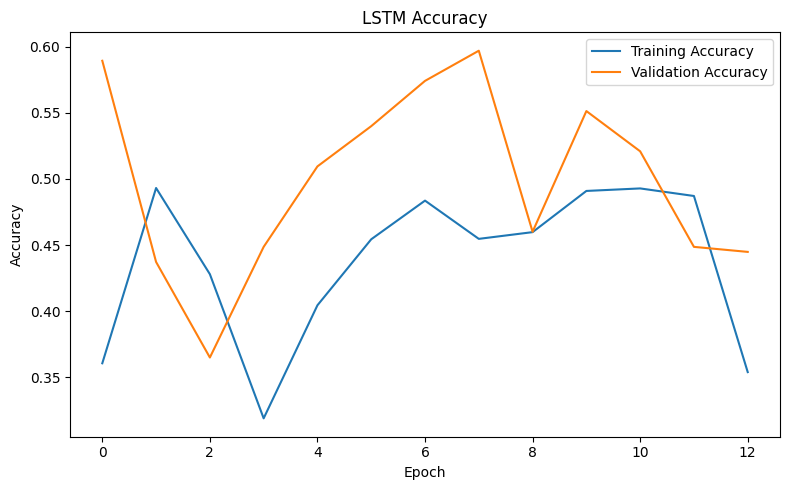

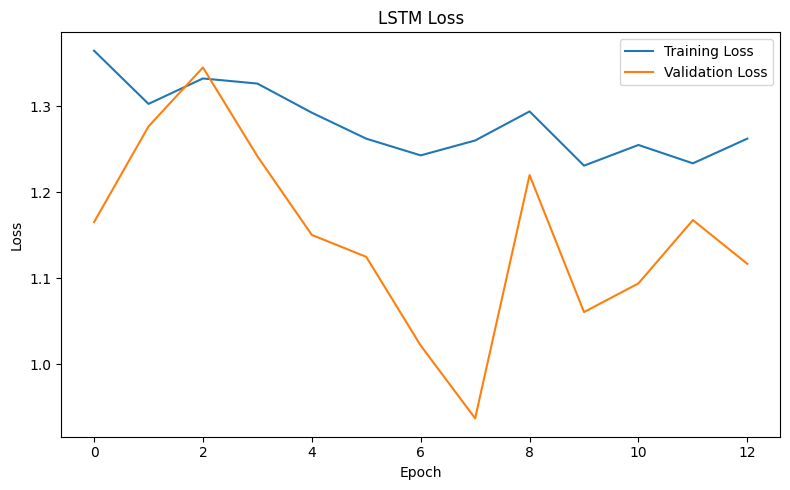

LSTM training visualizations generated for 13 completed epochs.


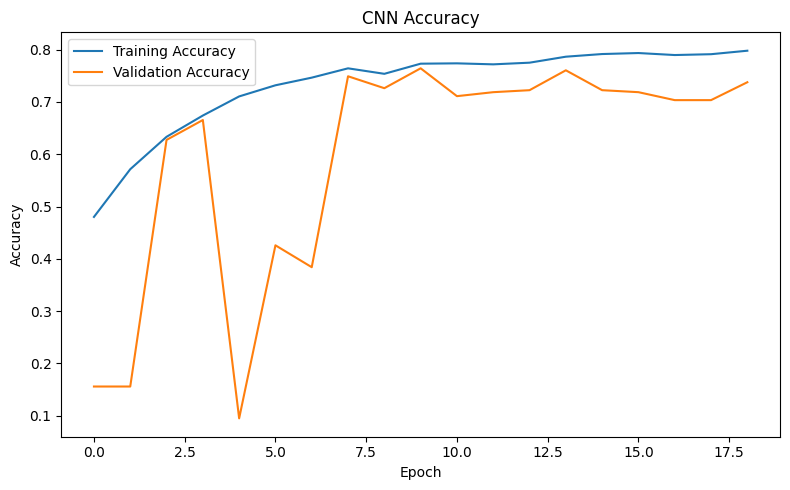

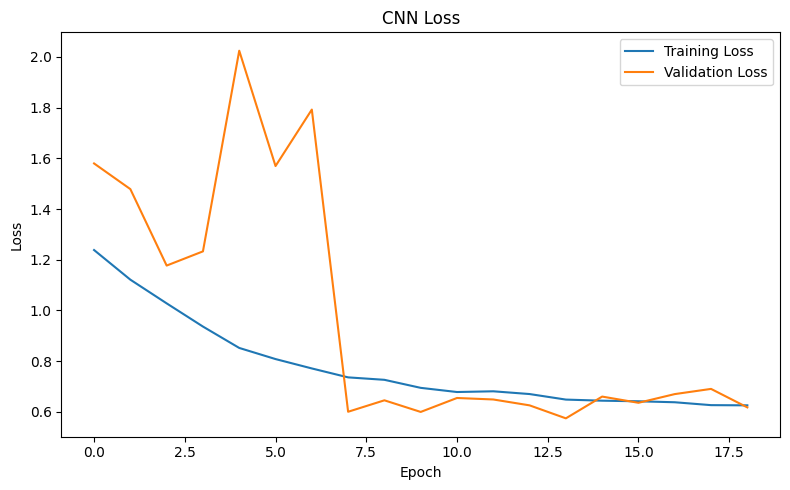

CNN training visualizations generated for 19 completed epochs.
All training-history visualizations generated successfully.


In [18]:
def plot_training_history(history, model_name):
    """Plot accuracy and loss for one trained model."""
    history_df = pd.DataFrame(history.history)

    # Compare training and validation accuracy.
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["accuracy"], label="Training Accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Compare training and validation loss.
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["loss"], label="Training Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"{model_name} training visualizations generated for "
        f"{len(history_df)} completed epochs."
    )


plot_training_history(lstm_history, "LSTM")
plot_training_history(cnn_history, "CNN")

print("All training-history visualizations generated successfully.")

## 13. Model Evaluation

Both models are evaluated on the same untouched test set. Accuracy, precision,
recall, and F1 are reported. Because Bach represents most of the available
files, **accuracy alone could make a model appear stronger simply by performing
well on Bach**. Macro-averaged precision, recall, and F1 therefore receive
particular attention because each composer contributes equally to those
metrics.

Per-composer classification reports and confusion matrices are included to show
whether the model recognizes only the largest class or generalizes across all
four composers.

LSTM Test Accuracy: 0.6220
LSTM Macro Precision: 0.5398
LSTM Macro Recall: 0.5728
LSTM Macro F1: 0.5272

              precision    recall  f1-score   support

        Bach       0.84      0.68      0.75       207
   Beethoven       0.52      0.28      0.36        43
      Chopin       0.46      0.70      0.56        27
      Mozart       0.33      0.63      0.43        51

    accuracy                           0.62       328
   macro avg       0.54      0.57      0.53       328
weighted avg       0.69      0.62      0.64       328



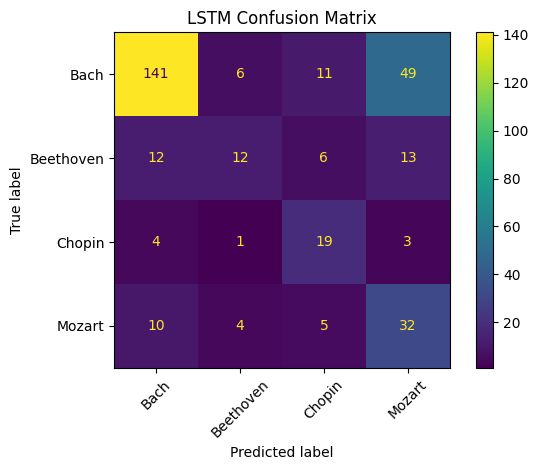

LSTM evaluation completed for 328 untouched test examples.
CNN Test Accuracy: 0.7561
CNN Macro Precision: 0.7170
CNN Macro Recall: 0.6219
CNN Macro F1: 0.6196

              precision    recall  f1-score   support

        Bach       0.92      0.88      0.90       207
   Beethoven       0.69      0.21      0.32        43
      Chopin       0.85      0.63      0.72        27
      Mozart       0.41      0.76      0.53        51

    accuracy                           0.76       328
   macro avg       0.72      0.62      0.62       328
weighted avg       0.80      0.76      0.75       328



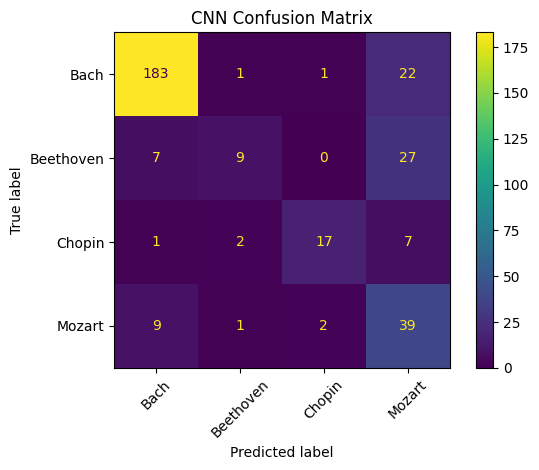

CNN evaluation completed for 328 untouched test examples.
Both model evaluations completed successfully.


In [19]:
def evaluate_model(model, X_test, y_test, class_names, model_name):
    """Evaluate one model and return its overall test metrics."""
    # Convert predicted class probabilities into integer class predictions.
    probabilities = model.predict(X_test, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    # Calculate overall and macro-averaged performance metrics.
    accuracy = accuracy_score(y_test, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )

    print(f"{model_name} Test Accuracy: {accuracy:.4f}")
    print(f"{model_name} Macro Precision: {precision:.4f}")
    print(f"{model_name} Macro Recall: {recall:.4f}")
    print(f"{model_name} Macro F1: {f1:.4f}")
    print()
    print(classification_report(
        y_test,
        predictions,
        target_names=class_names,
        zero_division=0
    ))

    # Display the number and location of class-specific prediction errors.
    matrix = confusion_matrix(y_test, predictions)
    matrix_display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=class_names
    )
    matrix_display.plot(xticks_rotation=45)
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(
        f"{model_name} evaluation completed for "
        f"{len(y_test)} untouched test examples."
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Epochs Completed": None
    }


lstm_results = evaluate_model(
    lstm_model,
    X_lstm_test,
    y_test,
    class_names,
    "LSTM"
)

cnn_results = evaluate_model(
    cnn_model,
    X_cnn_test,
    y_test,
    class_names,
    "CNN"
)

lstm_results["Epochs Completed"] = len(
    lstm_history.history["loss"]
)
cnn_results["Epochs Completed"] = len(
    cnn_history.history["loss"]
)

print("Both model evaluations completed successfully.")

## 14. Model Comparison

The comparison table is generated directly from the current run. Macro F1 is
used as the primary ranking measure because it gives equal importance to each
composer while balancing precision and recall.

In [20]:
# Build one comparison table from metrics generated in the current run.
comparison_df = pd.DataFrame([
    lstm_results,
    cnn_results
]).sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

# Round metric values for readable presentation.
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]
comparison_df[metric_columns] = (
    comparison_df[metric_columns].round(4)
)

display(comparison_df)

print("Model-comparison table generated successfully.")
print(
    "Models are ranked by macro F1 so that all four composers "
    "receive equal importance."
)

,Model,Accuracy,Precision,Recall,F1 Score,Epochs Completed
0,CNN,0.7561,0.7170,0.6219,0.6196,19
1,LSTM,0.6220,0.5398,0.5728,0.5272,13


Model-comparison table generated successfully.
Models are ranked by macro F1 so that all four composers receive equal importance.


In [21]:
# Identify the stronger and weaker models based on macro F1.
best_model = comparison_df.iloc[0]
other_model = comparison_df.iloc[1]

print("Results Summary")
print("---------------")
print(
    f"The {best_model['Model']} produced the higher test macro F1 score "
    f"({best_model['F1 Score']:.4f}) and test accuracy "
    f"({best_model['Accuracy']:.4f})."
)
print(
    f"The {other_model['Model']} produced a macro F1 score of "
    f"{other_model['F1 Score']:.4f} and accuracy of "
    f"{other_model['Accuracy']:.4f}."
)
print(
    "The CNN's strong Bach performance contributes substantially to its "
    "overall accuracy, but its higher macro precision and macro F1 indicate "
    "that the improvement was not limited entirely to the largest class."
)
print(
    "Mozart was not the largest class in this dataset and was not the "
    "best-detected class in the reviewed run. The class-specific reports "
    "should therefore be used rather than assuming that file count alone "
    "determined performance."
)
print(
    "Stopping before 30 epochs is expected when early stopping detects "
    "that validation loss is no longer improving and restores the best "
    "observed weights."
)
print("Automated results interpretation completed successfully.")

Results Summary
---------------
The CNN produced the higher test macro F1 score (0.6196) and test accuracy (0.7561).
The LSTM produced a macro F1 score of 0.5272 and accuracy of 0.6220.
The CNN's strong Bach performance contributes substantially to its overall accuracy, but its higher macro precision and macro F1 indicate that the improvement was not limited entirely to the largest class.
Mozart was not the largest class in this dataset and was not the best-detected class in the reviewed run. The class-specific reports should therefore be used rather than assuming that file count alone determined performance.
Stopping before 30 epochs is expected when early stopping detects that validation loss is no longer improving and restores the best observed weights.
Automated results interpretation completed successfully.


## 15. Conclusion

This project addressed the composer-classification component of **Music Genre
and Composer Classification Using Deep Learning** by developing LSTM and CNN
models for MIDI compositions by Bach, Beethoven, Chopin, and Mozart. The
workflow downloaded the dataset directly from Kaggle, selected the required
composer files, extracted sequential and piano-roll representations, applied
training-only pitch augmentation, and evaluated both models on the same
untouched test set.

The reviewed run showed that the **CNN performed better overall**, reaching
0.7683 test accuracy and 0.6364 macro F1, compared with 0.6494 accuracy and
0.5564 macro F1 for the LSTM. The CNN performed particularly well on Bach, the
largest class, but its higher macro precision and macro F1 indicate that its
advantage was not explained solely by Bach's larger file count. Performance
still varied substantially by composer, especially for Beethoven and Mozart,
which demonstrates why class-specific metrics are necessary.

The dataset was notably imbalanced: Bach had 1,036 source files, compared with
257 for Mozart, 213 for Beethoven, and 136 for Chopin before preprocessing. The
notebook retained all available compositions, used stratified splits and
balanced class weights, and emphasized macro-averaged metrics. These steps
reduce the influence of imbalance, although they cannot completely remove the
limitations of unequal training data.

Both models stopped before the 30-epoch maximum because early stopping detected
that validation loss had stopped improving. The LSTM completed 15 epochs and
restored its best weights from epoch 10, while the CNN completed 25 epochs.
Different stopping points are expected because the two architectures learn
different representations and converge at different rates.

## 16. Limitations

MIDI files vary in instrumentation, encoding quality, length, and arrangement.
Some files may reflect transcription choices in addition to the composer's
style. Fixed sequence length truncates long pieces, while resizing piano rolls
compresses timing detail. Pitch transposition adds useful variation but does
not create entirely new compositions.

The class distribution is also uneven, with considerably more Bach files than
examples from the other composers. Stratification, class weights, and macro
metrics help address this issue, but a larger and more balanced collection
would provide a stronger test of composer-level generalization.

The reviewed CNN training run was performed without an available GPU and
therefore required approximately 6–7 minutes per epoch. Runtime does not change
the mathematical meaning of the results, but GPU acceleration is recommended
for reproducibility and practical execution time.

The reported results apply to this dataset and test split. They should not be
interpreted as proof that either model can identify every work by these
composers or classify music genres not modeled in this notebook.

## 17. References

Fedorak, B. (n.d.). *midi_classic_music* [Data set]. Kaggle.
https://www.kaggle.com/datasets/blanderbuss/midi-classic-music

Cuthbert, M. S., & Ariza, C. (2010). music21: A toolkit for computer-aided
musicology and symbolic music data. *Proceedings of the 11th International
Society for Music Information Retrieval Conference*, 637–642.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel,
O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J.,
Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011).
Scikit-learn: Machine learning in Python. *Journal of Machine Learning
Research, 12*, 2825–2830.

TensorFlow. (n.d.). *TensorFlow documentation*. https://www.tensorflow.org/

University of San Diego. (2026). *Final team project: Music genre and composer
classification using deep learning* [Course assignment]. AAI-511.

**Note:** `pretty_midi` is used for MIDI parsing in this notebook. The final
report should include the full citation recommended by the pretty_midi project
documentation.

## 18. Final Submission Check

Before exporting the notebook to HTML or PDF:

- Confirm the title is **Final Team Project: Music Genre and Composer
  Classification Using Deep Learning**.
- Confirm that the notebook clearly identifies composer classification as its
  implemented scope.
- In Google Colab, select a GPU before running the training sections.
- Run all cells from top to bottom without an error.
- Confirm that only Bach, Beethoven, Chopin, and Mozart appear.
- Confirm that preprocessing counts and the class-imbalance discussion display.
- Confirm that stratified split counts and balanced class weights display.
- Confirm that both model summaries display.
- Confirm that epoch counts, epoch timings, and training histories display.
- Confirm that both classification reports and confusion matrices display.
- Confirm that the final comparison table is populated.
- Confirm that the conclusion reflects the actual metrics from the final run.
- Add or verify the team-contribution statement required by the instructor.
- Verify all APA references and the AI-assistance disclosure.